In [ ]:
import os
import zipfile

# Set the paths
celeba_zip = "/content/drive/MyDrive/CelebA/calebA.zip"
monet_zip = "/content/drive/MyDrive/CelebA/monet.zip"

# Set the extraction directories
celeba_extract_to = "/content/data/celeba"
monet_extract_to = "/content/data/monet2photo"

# Make directories
os.makedirs(celeba_extract_to, exist_ok=True)
os.makedirs(monet_extract_to, exist_ok=True)

# Extract CelebA
with zipfile.ZipFile(celeba_zip, 'r') as zip_ref:
    zip_ref.extractall(celeba_extract_to)
print("✅ CelebA extracted to:", celeba_extract_to)

# Extract Monet2Photo
with zipfile.ZipFile(monet_zip, 'r') as zip_ref:
    zip_ref.extractall(monet_extract_to)
print("✅ Monet2Photo extracted to:", monet_extract_to)


✅ CelebA extracted to: /content/data/celeba
✅ Monet2Photo extracted to: /content/data/monet2photo


In [ ]:
import shutil
from pathlib import Path

celeba_dir = os.path.join(celeba_extract_to, "img_align_celeba", "img_align_celeba")
monet_dir = os.path.join(monet_extract_to, "trainA")  # if Monet2Photo uses trainA as paintings

# Now use these in your image copying section

output_dir = "/content/cyclegan_data"

trainA_dir = os.path.join(output_dir, "trainA")
trainB_dir = os.path.join(output_dir, "trainB")
os.makedirs(trainA_dir, exist_ok=True)
os.makedirs(trainB_dir, exist_ok=True)

valid_exts = [".jpg", ".jpeg", ".png"]

def copy_images(src, dst, max_images=10000):
    files = sorted([f for f in os.listdir(src) if os.path.splitext(f)[1].lower() in valid_exts])
    for i, fname in enumerate(files[:max_images]):
        shutil.copy(os.path.join(src, fname), os.path.join(dst, fname))

copy_images(celeba_dir, trainA_dir, 10000)
copy_images(monet_dir, trainB_dir, 10000)

print("✅ Images copied. TrainA:", len(os.listdir(trainA_dir)), "| TrainB:", len(os.listdir(trainB_dir)))


✅ Images copied. TrainA: 10000 | TrainB: 1072


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, utils
from PIL import Image
import matplotlib.pyplot as plt
import itertools


In [ ]:
class ImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        self.files_A = sorted(Path(root, "trainA").glob("*"))
        self.files_B = sorted(Path(root, "trainB").glob("*"))

    def __len__(self):
        return min(len(self.files_A), len(self.files_B))

    def __getitem__(self, idx):
        img_A = Image.open(self.files_A[idx]).convert("RGB")
        img_B = Image.open(self.files_B[idx]).convert("RGB")

        if self.transform:
            img_A = self.transform(img_A)
            img_B = self.transform(img_B)

        return {"A": img_A, "B": img_B}


In [ ]:
class ResnetBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(dim, dim, 3, 1, 1),
            nn.InstanceNorm2d(dim),
            nn.ReLU(True),
            nn.Conv2d(dim, dim, 3, 1, 1),
            nn.InstanceNorm2d(dim)
        )

    def forward(self, x):
        return x + self.block(x)

class Generator(nn.Module):
    def __init__(self, in_nc, out_nc, n_res=6):
        super().__init__()
        model = [
            nn.Conv2d(in_nc, 64, 7, 1, 3),
            nn.InstanceNorm2d(64),
            nn.ReLU(True),

            nn.Conv2d(64, 128, 3, 2, 1),
            nn.InstanceNorm2d(128),
            nn.ReLU(True),

            nn.Conv2d(128, 256, 3, 2, 1),
            nn.InstanceNorm2d(256),
            nn.ReLU(True),
        ]
        model += [ResnetBlock(256) for _ in range(n_res)]

        model += [
            nn.ConvTranspose2d(256, 128, 3, 2, 1, output_padding=1),
            nn.InstanceNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 3, 2, 1, output_padding=1),
            nn.InstanceNorm2d(64),
            nn.ReLU(True),

            nn.Conv2d(64, out_nc, 7, 1, 3),
            nn.Tanh()
        ]
        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self, in_nc):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_nc, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(256, 512, 4, 1, 1),
            nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(512, 1, 4, 1, 1),
        )

    def forward(self, x):
        return self.model(x)


In [ ]:
def denorm(x):
    return x * 0.5 + 0.5

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset = ImageDataset(output_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G_AB = Generator(3, 3).to(device)
G_BA = Generator(3, 3).to(device)
D_A = Discriminator(3).to(device)
D_B = Discriminator(3).to(device)

criterion_GAN = nn.MSELoss()
criterion_cycle = nn.L1Loss()

optim_G = optim.Adam(itertools.chain(G_AB.parameters(), G_BA.parameters()), lr=2e-4, betas=(0.5, 0.999))
optim_D_A = optim.Adam(D_A.parameters(), lr=2e-4, betas=(0.5, 0.999))
optim_D_B = optim.Adam(D_B.parameters(), lr=2e-4, betas=(0.5, 0.999))

os.makedirs("outputs", exist_ok=True)

num_epochs = 20
for epoch in range(1, num_epochs+1):
    for batch in dataloader:
        real_A = batch["A"].to(device)
        real_B = batch["B"].to(device)

        # Train Generators
        optim_G.zero_grad()
        fake_B = G_AB(real_A)
        fake_A = G_BA(real_B)

        loss_GAN_AB = criterion_GAN(D_B(fake_B), torch.ones_like(D_B(fake_B)))
        loss_GAN_BA = criterion_GAN(D_A(fake_A), torch.ones_like(D_A(fake_A)))

        recov_A = G_BA(fake_B)
        recov_B = G_AB(fake_A)

        loss_cycle_A = criterion_cycle(recov_A, real_A)
        loss_cycle_B = criterion_cycle(recov_B, real_B)

        loss_G = loss_GAN_AB + loss_GAN_BA + 10 * (loss_cycle_A + loss_cycle_B)
        loss_G.backward()
        optim_G.step()

        # Discriminator A
        optim_D_A.zero_grad()
        loss_D_A = 0.5 * (criterion_GAN(D_A(real_A), torch.ones_like(D_A(real_A))) +
                          criterion_GAN(D_A(fake_A.detach()), torch.zeros_like(D_A(fake_A))))
        loss_D_A.backward()
        optim_D_A.step()

        # Discriminator B
        optim_D_B.zero_grad()
        loss_D_B = 0.5 * (criterion_GAN(D_B(real_B), torch.ones_like(D_B(real_B))) +
                          criterion_GAN(D_B(fake_B.detach()), torch.zeros_like(D_B(fake_B))))
        loss_D_B.backward()
        optim_D_B.step()

    print(f"Epoch {epoch} | G Loss: {loss_G.item():.4f} | D_A Loss: {loss_D_A.item():.4f} | D_B Loss: {loss_D_B.item():.4f}")

    # Save generated samples
    if epoch % 5 == 0:
        G_AB.eval()
        with torch.no_grad():
            sample = next(iter(dataloader))["A"][:4].to(device)
            fake = G_AB(sample).cpu()
            real = sample.cpu()
            combined = torch.cat([denorm(real), denorm(fake)], dim=0)
            grid = utils.make_grid(combined, nrow=4)
            plt.figure(figsize=(8, 4))
            plt.imshow(grid.permute(1, 2, 0))
            plt.axis('off')
            plt.title(f"Epoch {epoch}")
            plt.savefig(f"outputs/cyclegan_epoch_{epoch}.png")
            plt.close()
        G_AB.train()


Epoch 1 | G Loss: 8.6097 | D_A Loss: 0.1562 | D_B Loss: 0.1439
Epoch 2 | G Loss: 4.7335 | D_A Loss: 0.1627 | D_B Loss: 0.1599
Epoch 3 | G Loss: 6.9699 | D_A Loss: 0.1487 | D_B Loss: 0.1611
Epoch 4 | G Loss: 4.1249 | D_A Loss: 0.2273 | D_B Loss: 0.1962
Epoch 5 | G Loss: 4.6176 | D_A Loss: 0.1538 | D_B Loss: 0.2070
Epoch 6 | G Loss: 4.3347 | D_A Loss: 0.1062 | D_B Loss: 0.0856
Epoch 7 | G Loss: 4.2677 | D_A Loss: 0.1940 | D_B Loss: 0.2307
Epoch 8 | G Loss: 4.1770 | D_A Loss: 0.1187 | D_B Loss: 0.1149
Epoch 9 | G Loss: 4.3416 | D_A Loss: 0.1232 | D_B Loss: 0.1767
Epoch 10 | G Loss: 4.9588 | D_A Loss: 0.0465 | D_B Loss: 0.0955
Epoch 11 | G Loss: 4.5287 | D_A Loss: 0.0578 | D_B Loss: 0.1905
Epoch 12 | G Loss: 3.9835 | D_A Loss: 0.1128 | D_B Loss: 0.2143
Epoch 13 | G Loss: 4.0403 | D_A Loss: 0.1116 | D_B Loss: 0.2076
Epoch 14 | G Loss: 4.1352 | D_A Loss: 0.0526 | D_B Loss: 0.1236
Epoch 15 | G Loss: 4.0095 | D_A Loss: 0.1131 | D_B Loss: 0.1810
Epoch 16 | G Loss: 4.1504 | D_A Loss: 0.0948 | D_

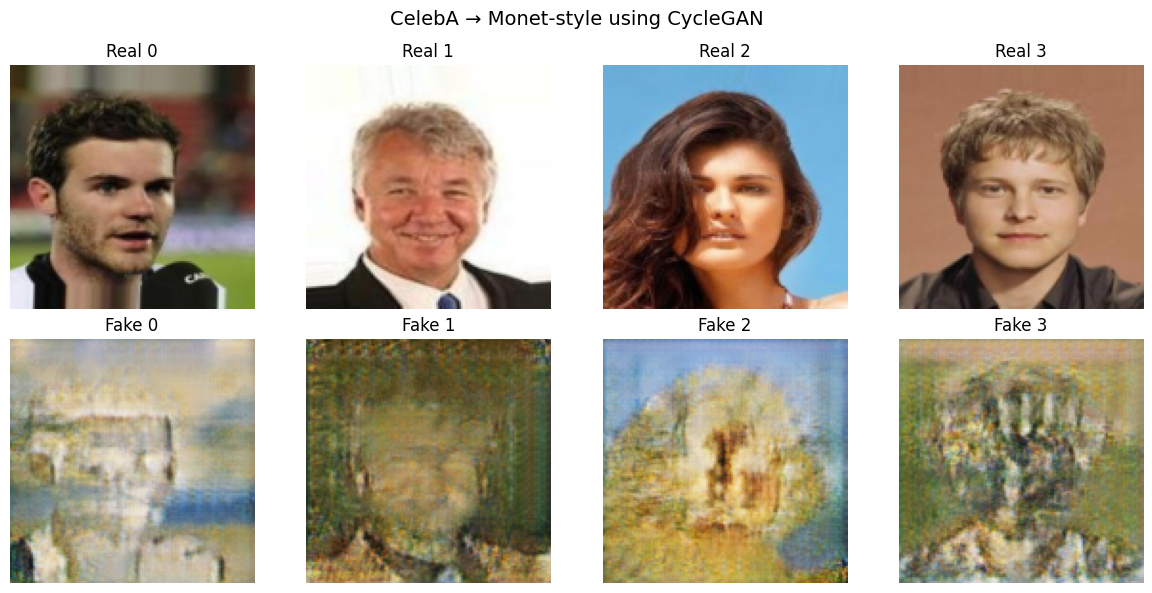

In [ ]:
num_samples = 4  # Number of examples to show (max batch size)

plt.figure(figsize=(num_samples * 3, 6))  # Wider figure for multiple images

for i in range(num_samples):
    real_img = denorm(real[i]).permute(1, 2, 0).numpy()
    fake_img = denorm(fake[i]).permute(1, 2, 0).numpy()

    # Original CelebA (top row)
    plt.subplot(2, num_samples, i + 1)
    plt.imshow(real_img)
    plt.title(f"Real {i}")
    plt.axis("off")

    # Monet-style output (bottom row)
    plt.subplot(2, num_samples, i + 1 + num_samples)
    plt.imshow(fake_img)
    plt.title(f"Fake {i}")
    plt.axis("off")

plt.suptitle("CelebA → Monet-style using CycleGAN", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
import shutil

src = '/content/outputs'
dst = '/content/drive/MyDrive/Backup_celeb/cycleGan'

shutil.copytree(src, dst)


'/content/drive/MyDrive/Backup_celeb/cycleGan'